# 01 — Data Preparation

**Fase 0** — Penggabungan dua sumber dataset Kaggle ke `dataset/processed/`

**5 kelas final (Bahasa Indonesia):** Cerah, Mendung, Hujan, Berawan, Berkabut
**170 citra per kelas → total 850 citra**

| Sumber | Folder Asli | → Kelas Final | Jumlah Dipakai |
|--------|-------------|---------------|----------------|
| Source 2 (jonathanvitotaufik) | Cerah | Cerah | 170 (semua) |
| Source 2 (jonathanvitotaufik) | Hujan | Hujan | 170 (semua) |
| Source 2 (jonathanvitotaufik) | Mendung | Mendung | 170 (semua) |
| Source 1 (vijayvkb98) | Cloudy | Berawan | 170 (sampling) |
| Source 1 (vijayvkb98) | Fog | Berkabut | 170 (sampling) |

**Rename file:** `{kelas}_{urutan:04d}.{ext}` (mencegah bentrok nama antar sumber)

**Manifest columns:** `filename_baru`, `kelas`, `sumber_asal`, `filename_asli`

---

**Langkah-langkah:**
1. Konfigurasi
2. Salin Source 2 (Cerah, Hujan, Mendung — semua citra)
3. Sampling Source 1 (Cloudy → Berawan, Fog → Berkabut, 170 tiap kelas)
4. Simpan ke `dataset/processed/{Kelas}/` dengan rename
5. Buat manifest.csv
6. Sanity check (jumlah + buka file)
7. Visualisasi cepat

## Langkah 1 — Konfigurasi

In [1]:
import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

# Seed untuk reproducibility (sampling Source 1 + rename counter)
RANDOM_STATE = 42

# Path absolut — sesuaikan jika struktur folder berbeda
REPO_ROOT = Path("/media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR")

SOURCE_1_DIR = REPO_ROOT / "dataset" / "raw" / "Source 1 (vijayvkb98)"
SOURCE_2_DIR = REPO_ROOT / "dataset" / "raw" / "Source 2 (jonathanvitotaufik)"
PROCESSED_DIR = REPO_ROOT / "dataset" / "processed"
RESULTS_DIR   = REPO_ROOT / "results"

# 5 kelas final Bahasa Indonesia
KLAS_FINAL = ["Cerah", "Mendung", "Hujan", "Berawan", "Berkabut"]

# Pemetaan: folder_asli → kelas_final
# Source 1 (vijayvkb98) — hanya Cloudy & Fog yang dipakai
MAPPING_SOURCE_1 = {
    "Cloudy": "Berawan",
    "Fog":    "Berkabut",
}

# Source 2 (jonathanvitotaufik) — langsung pakai, nama folder = kelas
MAPPING_SOURCE_2 = {
    "Cerah":  "Cerah",
    "Hujan":  "Hujan",
    "Mendung": "Mendung",
}

# Jumlah citra per kelas target
TARGET_PER_CLASS = 170

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Repo root  : {REPO_ROOT}")
print(f"Source 1   : {SOURCE_1_DIR}")
print(f"Source 2   : {SOURCE_2_DIR}")
print(f"Processed  : {PROCESSED_DIR}")
print(f"Target/citrc/kelas: {TARGET_PER_CLASS}")

Repo root  : /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR
Source 1   : /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/dataset/raw/Source 1 (vijayvkb98)
Source 2   : /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/dataset/raw/Source 2 (jonathanvitotaufik)
Processed  : /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/dataset/processed
Target/citrc/kelas: 170


## Langkah 2 — Salin Source 2 (Cerah, Hujan, Mendung — semua citra)

In [2]:
def salin_seluruh_folder(src_dir: Path, kelas_final: str) -> list[tuple[str, str]]:
    """
    Salin SEMUA citra dari folder sumber ke kelas_final.
    Returns list of (filename_baru, filename_asli).
    """
    dest_dir = PROCESSED_DIR / kelas_final
    dest_dir.mkdir(parents=True, exist_ok=True)

    semua_file = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        semua_file.extend(sorted(src_dir.glob(ext)))

    records = []
    for idx, src_path in enumerate(semua_file):
        ext = src_path.suffix.lower()
        # Normalisasi ekstensi: .jpeg → .jpg
        if ext == ".jpeg":
            ext = ".jpg"
        filename_baru = f"{kelas_final}_{idx + 1:04d}{ext}"
        dest_path = dest_dir / filename_baru

        shutil.copy2(src_path, dest_path)
        records.append((filename_baru, src_path.name))

    return records


all_records = []   # akan berisi dict untuk setiap citra

print("=== Source 2: jonathanvitotaufik (seluruh citra) ===")
for folder_name, kelas_final in MAPPING_SOURCE_2.items():
    src_dir = SOURCE_2_DIR / folder_name
    records = salin_seluruh_folder(src_dir, kelas_final)
    print(f"  {folder_name:10s} → {kelas_final:10s}: {len(records):3d} citra")
    for fname_baru, fname_asli in records:
        all_records.append({
            "filename_baru": fname_baru,
            "kelas":         kelas_final,
            "sumber_asal":   "Source 2 (jonathanvitotaufik)",
            "filename_asli": fname_asli,
        })

print(f"\nTotal citra dari Source 2: {len(all_records)}")

=== Source 2: jonathanvitotaufik (seluruh citra) ===


  Cerah      → Cerah     : 170 citra


  Hujan      → Hujan     : 170 citra


  Mendung    → Mendung   : 170 citra

Total citra dari Source 2: 510


## Langkah 3 — Sampling Source 1 (Cloudy → Berawan, Fog → Berkabut)

In [3]:
def salin_sampling_folder(src_dir: Path, kelas_final: str, n: int) -> list[tuple[str, str]]:
    """
    Sampling N citra AC dari folder sumber, salin ke kelas_final.
    Returns list of (filename_baru, filename_asli).
    """
    dest_dir = PROCESSED_DIR / kelas_final
    dest_dir.mkdir(parents=True, exist_ok=True)

    semua_file = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        semua_file.extend(sorted(src_dir.glob(ext)))

    if len(semua_file) < n:
        raise ValueError(
            f"Folder {src_dir.name} hanya punya {len(semua_file)} citra, "
            f"butuh {n} untuk {kelas_final}"
        )

    # Sampling acak — random_state di-seed via random.seed() global
    sampled = random.sample(semua_file, n)

    records = []
    for idx, src_path in enumerate(sampled):
        ext = src_path.suffix.lower()
        if ext == ".jpeg":
            ext = ".jpg"
        filename_baru = f"{kelas_final}_{idx + 1:04d}{ext}"
        dest_path = dest_dir / filename_baru

        shutil.copy2(src_path, dest_path)
        records.append((filename_baru, src_path.name))

    return records


print("=== Source 1: vijayvkb98 (sampling 170 tiap kelas) ===")
for folder_name, kelas_final in MAPPING_SOURCE_1.items():
    src_dir = SOURCE_1_DIR / folder_name
    records = salin_sampling_folder(src_dir, kelas_final, TARGET_PER_CLASS)
    print(f"  {folder_name:10s} → {kelas_final:10s}: {len(records):3d} citra")
    for fname_baru, fname_asli in records:
        all_records.append({
            "filename_baru": fname_baru,
            "kelas":         kelas_final,
            "sumber_asal":   "Source 1 (vijayvkb98)",
            "filename_asli": fname_asli,
        })

print(f"\nTotal citra dari Source 1: "
      f"{len([r for r in all_records if 'Source 1' in r['sumber_asal']])}")

=== Source 1: vijayvkb98 (sampling 170 tiap kelas) ===
  Cloudy     → Berawan   : 170 citra


  Fog        → Berkabut  : 170 citra

Total citra dari Source 1: 340


## Langkah 4 & 5 — Simpan ke `dataset/processed/` + Buat manifest.csv

*(Simpannya sudah terjadi di Langkah 2 & 3 — di sini hanya menulis manifest)*

In [4]:
# Buat DataFrame dari semua records dan urutkan
manifest_df = pd.DataFrame(all_records, columns=["filename_baru", "kelas", "sumber_asal", "filename_asli"])
manifest_df = manifest_df.sort_values(["kelas", "filename_baru"]).reset_index(drop=True)

# Simpan manifest.csv
manifest_path = PROCESSED_DIR / "manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print(f"Manifest disimpan: {manifest_path}")
print(f"Total baris: {len(manifest_df)}")
print()
print(manifest_df.head(10).to_string(index=False))

Manifest disimpan: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/dataset/processed/manifest.csv
Total baris: 850

   filename_baru   kelas           sumber_asal filename_asli
Berawan_0001.jpg Berawan Source 1 (vijayvkb98) cloudy148.jpg
Berawan_0002.jpg Berawan Source 1 (vijayvkb98)  cloudy11.jpg
Berawan_0003.jpg Berawan Source 1 (vijayvkb98) cloudy216.jpg
Berawan_0004.jpg Berawan Source 1 (vijayvkb98) cloudy202.jpg
Berawan_0005.jpg Berawan Source 1 (vijayvkb98) cloudy193.jpg
Berawan_0006.jpg Berawan Source 1 (vijayvkb98) cloudy160.jpg
Berawan_0007.jpg Berawan Source 1 (vijayvkb98) cloudy143.jpg
Berawan_0008.jpg Berawan Source 1 (vijayvkb98)   cloudy7.jpg
Berawan_0009.jpg Berawan Source 1 (vijayvkb98) cloudy137.jpg
Berawan_0010.jpg Berawan Source 1 (vijayvkb98)  cloudy90.jpg


## Langkah 6 — Sanity Check

In [5]:
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)

# 6a. Hitung jumlah citra per kelas
jumlah_per_kelas = {}
for kelas in KLAS_FINAL:
    folder = PROCESSED_DIR / kelas
    file_list = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        file_list.extend(folder.glob(ext))
        file_list.extend(folder.glob(ext.upper()))
    # Hapus duplikat (jika ada .jpg dan .JPG)
    file_set = set(str(f) for f in file_list)
    jumlah_per_kelas[kelas] = len(file_set)

total_all = sum(jumlah_per_kelas.values())

print("\n[Jumlah citra per kelas]")
for kelas, jumlah in jumlah_per_kelas.items():
    status = "✓" if jumlah == TARGET_PER_CLASS else "✗ GAGAL"
    print(f"  {kelas:10s}: {jumlah:3d}  (target: {TARGET_PER_CLASS}) {status}")

total_status = "✓" if total_all == len(KLAS_FINAL) * TARGET_PER_CLASS else "✗ GAGAL"
print(f"  {'TOTAL':10s}: {total_all:3d}  (target: {len(KLAS_FINAL) * TARGET_PER_CLASS}) {total_status}")

# 6b. Cek file korup (bisa dibuka PIL)
print("\n[Cek file korup — buka semua citra dengan PIL]")
file_korup = []
for kelas in KLAS_FINAL:
    folder = PROCESSED_DIR / kelas
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        for img_path in folder.glob(ext):
            try:
                with Image.open(img_path) as img:
                    img.verify()  # verifikasi header file
            except Exception as e:
                file_korup.append((str(img_path), str(e)))

if not file_korup:
    print("  ✓ Tidak ada file korup")
else:
    print(f"  ✗ Ditemukan {len(file_korup)} file korup:")
    for path, err in file_korup:
        print(f"    - {path}: {err}")

# 6c. Summary
print("\n[Summary]")
all_ok = (
    all(j == TARGET_PER_CLASS for j in jumlah_per_kelas.values())
    and total_all == len(KLAS_FINAL) * TARGET_PER_CLASS
    and not file_korup
)
if all_ok:
    print("  ✓ SEMUA CHECK MEMENUHI SYARAT")
else:
    print("  ✗ ADA MASALAH — perbaiki sebelum lanjut ke Fase 1")

SANITY CHECK

[Jumlah citra per kelas]
  Cerah     : 170  (target: 170) ✓
  Mendung   : 170  (target: 170) ✓
  Hujan     : 170  (target: 170) ✓
  Berawan   : 170  (target: 170) ✓
  Berkabut  : 170  (target: 170) ✓
  TOTAL     : 850  (target: 850) ✓

[Cek file korup — buka semua citra dengan PIL]


  ✓ Tidak ada file korup

[Summary]
  ✓ SEMUA CHECK MEMENUHI SYARAT


## Langkah 7 — Visualisasi Cepat

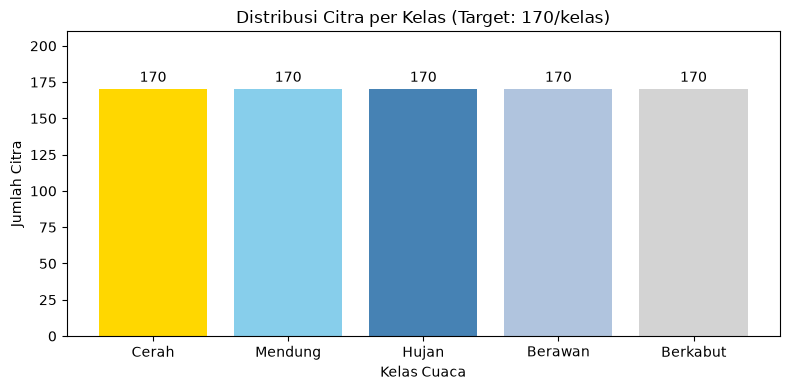

  Tersimpan: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/results/figures/distribusi_kelas.png


In [6]:
# 7a. Bar chart distribusi kelas
results_fig_dir = RESULTS_DIR / "figures"
results_fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    list(jumlah_per_kelas.keys()),
    list(jumlah_per_kelas.values()),
    color=["#FFD700", "#87CEEB", "#4682B4", "#B0C4DE", "#D3D3D3"]
)
ax.set_xlabel("Kelas Cuaca")
ax.set_ylabel("Jumlah Citra")
ax.set_title("Distribusi Citra per Kelas (Target: 170/kelas)")
ax.set_ylim(0, 210)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{int(bar.get_height())}",
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
dist_path = results_fig_dir / "distribusi_kelas.png"
plt.savefig(dist_path, dpi=150)
plt.show()
print(f"  Tersimpan: {dist_path}")

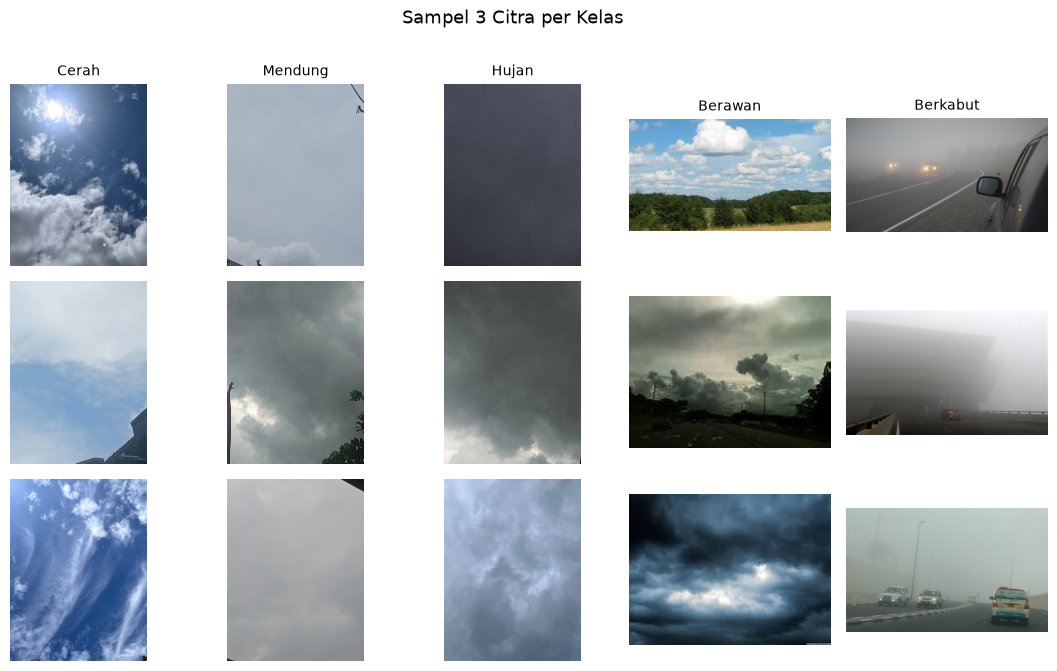

  Tersimpan: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/results/figures/sampel_per_kelas.png


In [7]:
# 7b. Grid sampel citra per kelas (3 citra acak per kelas)
n_cols = len(KLAS_FINAL)
n_rows_sample = 3

fig, axes = plt.subplots(
    nrows=n_rows_sample,
    ncols=n_cols,
    figsize=(n_cols * 2.2, n_rows_sample * 2.2)
)

for col, kelas in enumerate(KLAS_FINAL):
    folder = PROCESSED_DIR / kelas
    all_images = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        all_images.extend(folder.glob(ext))
        all_images.extend(folder.glob(ext.upper()))
    all_images = sorted(set(all_images))

    # 3 sampel acak (seed sudah diset di atas)
    sample_imgs = random.sample(all_images, min(3, len(all_images)))

    for row, img_path in enumerate(sample_imgs):
        ax = axes[row, col] if n_rows_sample > 1 else axes[col]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(kelas if row == 0 else "", fontsize=10)
        ax.axis("off")

    # Kalau kurang dari 3 (seharusnya tidak terjadi), kosongkan sisa cell
    for row in range(len(sample_imgs), n_rows_sample):
        ax = axes[row, col] if n_rows_sample > 1 else axes[col]
        ax.axis("off")

plt.suptitle("Sampel 3 Citra per Kelas", fontsize=13, y=1.01)
plt.tight_layout()
grid_path = results_fig_dir / "sampel_per_kelas.png"
plt.savefig(grid_path, dpi=150)
plt.show()
print(f"  Tersimpan: {grid_path}")

---

## Done — Fase 0 Selesai

Output:
- `dataset/processed/{Cerah,Mendung,Hujan,Berawan,Berkabut}/` — 170 citra/folder
- `dataset/processed/manifest.csv`
- `results/figures/distribusi_kelas.png`
- `results/figures/sampel_per_kelas.png`

下一步: **Fase 1** — Pipeline pra-pemrosesan & pembagian data stratified